# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example: notebooks/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/data/student-name/data.csv`).
    - (Create a new folder with your name)
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

#### 1.1 Retrieving Data for Dependent Variable: from FRED API (10-Year US Treasury Bond Yield, Monthly Frequency)

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np

# Function for data retrieval from FRED API
def FRED_API_OBS(series_id, observation_start = '', observation_end = ''):
    fred_url = "https://api.stlouisfed.org/fred/series/observations"
    fred_params = {
        'api_key' : 'd51b8baf0cb62af58079d6d18fe4e4e2',
        'file_type' : 'json',
        'series_id' : series_id,
        'observation_start' : observation_start,
        'observation_end': observation_end,
    }
    fred_response = requests.get(url = fred_url, params = fred_params)
    fred_response_json = fred_response.json() # Decode json-format response into Python dictionary
    fred_response_df = pd.DataFrame(fred_response_json['observations']) # Transform observations in decoded dictionary-format data into dataframe
    return fred_response_df

# Series_ID for US 10-year Treasury Bond yield is "GS10" (monthly frequency)
USTB10_Yield = FRED_API_OBS(series_id='GS10', observation_start='2007-01-01', observation_end='2026-05-27')
USTB10_Yield.head(3)

,realtime_start,realtime_end,date,value
0,2026-05-27,2026-05-27,2007-01-01,4.76
1,2026-05-27,2026-05-27,2007-02-01,4.72
2,2026-05-27,2026-05-27,2007-03-01,4.56


#### 1.2 Importing Data for Independent Variable: Local Data from Chinese National Bureau of Statistic (Excavator Production, Monthly Frequency)

In [2]:
# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
# print(os.getcwd())
print(os.listdir("../../../data/hw/hw_3/data/jerry-yu"))

# 2. Acquire and load your primary dataset
# Excavator Production data is only available in Chinese. 
excavator_CHN_monthly = pd.read_csv("../../../data/hw/hw_3/data/jerry-yu/excavator_CHN_monthly_zh.csv", encoding='utf-8')
# All cells in the .csv file are ended with a redundant "\t", which should be removed using regular expression.
excavator_CHN_monthly = excavator_CHN_monthly.replace(to_replace = r'\t', value = '', regex = True)
# All column names are also ended with a redundant "\t", similarly removed.
excavator_CHN_monthly.columns = excavator_CHN_monthly.columns.str.replace(pat = r'\t', repl = '', regex = True)
excavator_CHN_monthly.head(3)

['excavator_CHN_monthly_zh.csv']


,数据时间,挖掘机产量当期值 (台),挖掘机产量累计值 (台),挖掘机产量同比增长 (%),挖掘机产量累计增长 (%)
0,2026年4月,39389,151496,34.0,25.0
1,2026年3月,48427,112107,26.5,22.8
2,2026年2月,,63566,,22.5


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- **Dependent Variable (Y): United States 10-year Treasury Bond Yield**
    - Data source: FRED API (Federal Reserve Bank of St. Louis)
    - Frequency: Monthly 
    - API URL: https://api.stlouisfed.org/fred/series/observations (*Note: API Key registration required*)
    - PARAMETER: series_id = 'GS10'

- **Independent Variable (X): Excavator Production in China**
    - Data source: Chinese National Bureau of Statistics (国家统计局)
    - Frequency: Monthly
    - URL: https://data.stats.gov.cn/dg/website/page.html#/pc/national/monthData
    - PATH: 月度数据(Monthly data) > 工业(Industry) > 工业主要产品产量(Output of major industrial products) > 挖掘机(Excavator) (*Note: This series is only available in Chinese*)

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

#### 1. Excavator Production in China (Independent Variable)

In [3]:
# 1. Inspect data structure
excavator_CHN_monthly.info()
excavator_CHN_monthly.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   数据时间            232 non-null    str  
 1   挖掘机产量当期值 (台)    232 non-null    str  
 2   挖掘机产量累计值 (台)    232 non-null    str  
 3   挖掘机产量同比增长 (%)   232 non-null    str  
 4   挖掘机产量累计增长 (%)   232 non-null    str  
dtypes: str(5)
memory usage: 9.2 KB


,数据时间,挖掘机产量当期值 (台),挖掘机产量累计值 (台),挖掘机产量同比增长 (%),挖掘机产量累计增长 (%)
0,2026年4月,39389,151496,34.0,25.0
1,2026年3月,48427,112107,26.5,22.8
2,2026年2月,,63566,,22.5


In [4]:
### 2. Rename columns and Transform data format
## Rename columns
excavator_CHN_monthly_colnames_mapping = {
    '数据时间': 'date',
    '挖掘机产量当期值 (台) ': 'current_CHN_excavator_output',
    '挖掘机产量累计值 (台) ': 'cumulative_CHN_excavator_output',
    '挖掘机产量同比增长 (%) ': 'YoY_CHN_excavator_growth_rate',
    '挖掘机产量累计增长 (%) ': 'cumulative_CHN_excavator_growth_rate'
}
excavator_CHN_monthly = excavator_CHN_monthly.rename(columns = excavator_CHN_monthly_colnames_mapping)

## Transform date format
# Replace Kanji with "-"
date_format_mapping = {
    '年': '-',
    '月': '',
}
excavator_CHN_monthly['date'] = excavator_CHN_monthly['date'].replace(date_format_mapping, regex=True)
# Standardize date format using pandas
excavator_CHN_monthly['date'] = pd.to_datetime(excavator_CHN_monthly['date'], format='%Y-%m')

## Transform string into numeric in other columns
for col in excavator_CHN_monthly.columns[1:]:
    excavator_CHN_monthly[col] = pd.to_numeric(excavator_CHN_monthly[col])

# Re-check
excavator_CHN_monthly.info()
excavator_CHN_monthly.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  232 non-null    datetime64[us]
 1   current_CHN_excavator_output          205 non-null    float64       
 2   cumulative_CHN_excavator_output       218 non-null    float64       
 3   YoY_CHN_excavator_growth_rate         204 non-null    float64       
 4   cumulative_CHN_excavator_growth_rate  217 non-null    float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 9.2 KB


,date,current_CHN_excavator_output,cumulative_CHN_excavator_output,YoY_CHN_excavator_growth_rate,cumulative_CHN_excavator_growth_rate
0,2026-04-01,39389.0,151496.0,34.0,25.0
1,2026-03-01,48427.0,112107.0,26.5,22.8
2,2026-02-01,NaN,63566.0,NaN,22.5


In [5]:
## 3-4. Select subset, Filter row or column filters & Handle missing values (NaNs)
# Select subset (only current-period output and YoY growth rate)
excavator_CHN_monthly_current = excavator_CHN_monthly[['date', 'current_CHN_excavator_output', 'YoY_CHN_excavator_growth_rate']]
# Filter out negative values (if exist) and NaNs
excavator_CHN_monthly_current = excavator_CHN_monthly_current.query("current_CHN_excavator_output >= 0")
# Remove NaNs (though already removed in the previous step)
excavator_CHN_monthly_current = excavator_CHN_monthly_current.dropna()

# Re-check
excavator_CHN_monthly_current.head(3)


,date,current_CHN_excavator_output,YoY_CHN_excavator_growth_rate
0,2026-04-01,39389.0,34.0
1,2026-03-01,48427.0,26.5
4,2025-12-01,37305.0,20.8


#### 2. US 10-Year Treasury Bond Yield (Dependent Variable)

In [6]:
# 1. Inspect data structure
USTB10_Yield.info()
USTB10_Yield.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   realtime_start  232 non-null    str  
 1   realtime_end    232 non-null    str  
 2   date            232 non-null    str  
 3   value           232 non-null    str  
dtypes: str(4)
memory usage: 7.4 KB


,realtime_start,realtime_end,date,value
0,2026-05-27,2026-05-27,2007-01-01,4.76
1,2026-05-27,2026-05-27,2007-02-01,4.72
2,2026-05-27,2026-05-27,2007-03-01,4.56


In [7]:
### 2. Rename columns, Select subset & Transform data format
## Rename value column
USTB10_Yield = USTB10_Yield.rename(columns={
    'value': 'USTB_10Y_yield'
})
## Select only date and value columns
USTB10_Yield = USTB10_Yield[['date', 'USTB_10Y_yield']]

## Transform data format 
# Standardize date format
USTB10_Yield['date'] = pd.to_datetime(USTB10_Yield['date'], format='%Y-%m-%d')
# Transform value column from string to numeric
USTB10_Yield['USTB_10Y_yield'] = pd.to_numeric(USTB10_Yield['USTB_10Y_yield'])

# Re-check
USTB10_Yield.info()
USTB10_Yield.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            232 non-null    datetime64[us]
 1   USTB_10Y_yield  232 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 3.8 KB


,date,USTB_10Y_yield
0,2007-01-01,4.76
1,2007-02-01,4.72
2,2007-03-01,4.56


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [8]:
## Merge your datasets on a common key
# Date (month) as the key
merged_df = pd.merge(USTB10_Yield, excavator_CHN_monthly_current, on='date', how='inner')
# Set date as index
merged_df = merged_df.set_index('date')

## Display shape and head of merged dataset
print(f"The shape of merged dataset is: {merged_df.shape}")
merged_df.head(3)

The shape of merged dataset is: (204, 3)


,USTB_10Y_yield,current_CHN_excavator_output,YoY_CHN_excavator_growth_rate
date,,,
2007-01-01,4.76,1543.0,72.6
2007-02-01,4.72,1272.0,6.1
2007-03-01,4.56,2543.0,-1.3


In [9]:
# Count the number of observations after merging
merged_df.describe()

,USTB_10Y_yield,current_CHN_excavator_output,YoY_CHN_excavator_growth_rate
count,204.000000,204.000000,204.000000
mean,2.844461,17206.127451,16.615686
std,1.069134,10636.626215,37.639194
min,0.620000,1272.000000,-58.900000
25%,2.032500,8765.000000,-15.350000
50%,2.745000,15868.500000,13.300000
75%,3.722500,24633.750000,48.175000
max,5.100000,58429.000000,122.700000


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- **Merge Key**: month (Variable: *date*)
- **Observations Retained**: 204 (*"inner" as merging method*)

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

#### 1. Setting Criteria and Thresholds: Date (GFC-Pandemic)

In [10]:
## Backup strategy: Binning (partition dates into different eras, with Global Financial Crisis & Covid Pandemic as two critical junctures)
# Define critical junctures (point-in-time)
era_thresholds = [merged_df.index.min(), pd.Timestamp('2010-01-01'), pd.Timestamp('2020-01-01'), merged_df.index.max()]
# Define eras between critical junctures
era_labels = ['intra-GFC', 'post-GFC-pre-Pandemic', 'intra-post-Pandemic']
# Apply the partition criteria to merged data to create a new column
merged_df['era'] = pd.cut(merged_df.index, bins=era_thresholds, labels=era_labels, include_lowest=True)

# Re-check
merged_df.head(3)

,USTB_10Y_yield,current_CHN_excavator_output,YoY_CHN_excavator_growth_rate,era
date,,,,
2007-01-01,4.76,1543.0,72.6,intra-GFC
2007-02-01,4.72,1272.0,6.1,intra-GFC
2007-03-01,4.56,2543.0,-1.3,intra-GFC


#### 2. Groupby Analysis: Descriptive Metrics

In [11]:
## Descriptive metrics: Average
merged_df_era_mean = merged_df.groupby('era').mean()
merged_df_era_mean

,USTB_10Y_yield,current_CHN_excavator_output,YoY_CHN_excavator_growth_rate
era,,,
intra-GFC,3.850556,5528.833333,27.080556
post-GFC-pre-Pandemic,2.396698,14908.179245,16.583019
intra-post-Pandemic,3.025806,27915.241935,10.595161


In [12]:
## Descriptive metrics: Median
merged_df.groupby('era').median()

,USTB_10Y_yield,current_CHN_excavator_output,YoY_CHN_excavator_growth_rate
era,,,
intra-GFC,3.735,4336.5,24.00
post-GFC-pre-Pandemic,2.310,13312.0,17.55
intra-post-Pandemic,3.690,26335.0,10.55


In [13]:
## Descriptive metrics: Max
merged_df.groupby('era').max()

,USTB_10Y_yield,current_CHN_excavator_output,YoY_CHN_excavator_growth_rate
era,,,
intra-GFC,5.10,12908.0,106.0
post-GFC-pre-Pandemic,3.85,33877.0,122.7
intra-post-Pandemic,4.80,58429.0,82.3


In [14]:
## Descriptive metrics: Min
merged_df.groupby('era').min()

,USTB_10Y_yield,current_CHN_excavator_output,YoY_CHN_excavator_growth_rate
era,,,
intra-GFC,2.42,1272.0,-32.9
post-GFC-pre-Pandemic,1.50,5584.0,-54.2
intra-post-Pandemic,0.62,13237.0,-58.9


- *Extra Credit: Write your economic or policy related interpretation here*
- Average US 10-year Treasury Bond Yield between GFC and Pandemic (i.e., "Inter-Crises Era") is significantly lower than that during GFC and post-Pandemic, partially reflecting the effect of unconventional monetary policies on long-term interest rate (espeically quantitative easing, which involved open market purchasing of Treasury Bonds with long maturities).
- Average YoY excavator output growth rate in China dropped significantly and sequentially from GFC, through post-GFC-pre-Pandemic period, to post-Pandemic era. **Excavator output is a leading indicator of construction and tangible asset investment**, which partially reflectes the gear-shifting of Chinese economy from high investment growth (before GFC and extending to China's "Four-Trillion Stimulus Package" period at the peak of GFC), through medium growth (echoing with so-called "New Normal of China's Economy" officially raised in 2014), to even lower growth (partially caused by real estate stagnation since 2021).

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

#### 1. Customized Bar Chart and Line Chart of Aggregated Subgroups

Text(0, 0.5, '%')

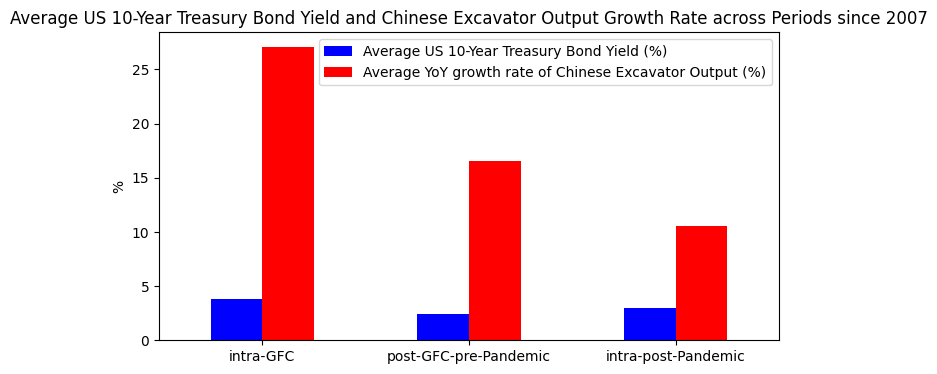

In [15]:
# Plot 1.1: Customized bar chart of aggregated subgroups
group_bar = merged_df[['USTB_10Y_yield','YoY_CHN_excavator_growth_rate','era']].groupby('era').mean().plot(
    kind='bar',figsize=(8,4),rot=0,color=['blue','red'])

plt.title('Average US 10-Year Treasury Bond Yield and Chinese Excavator Output Growth Rate across Periods since 2007')
plt.legend(['Average US 10-Year Treasury Bond Yield (%)','Average YoY growth rate of Chinese Excavator Output (%)'])
plt.xlabel('')
plt.ylabel('%')

Periods since 2007
intra-GFC                Axes(0.125,0.2;0.775x0.68)
post-GFC-pre-Pandemic    Axes(0.125,0.2;0.775x0.68)
intra-post-Pandemic      Axes(0.125,0.2;0.775x0.68)
dtype: object

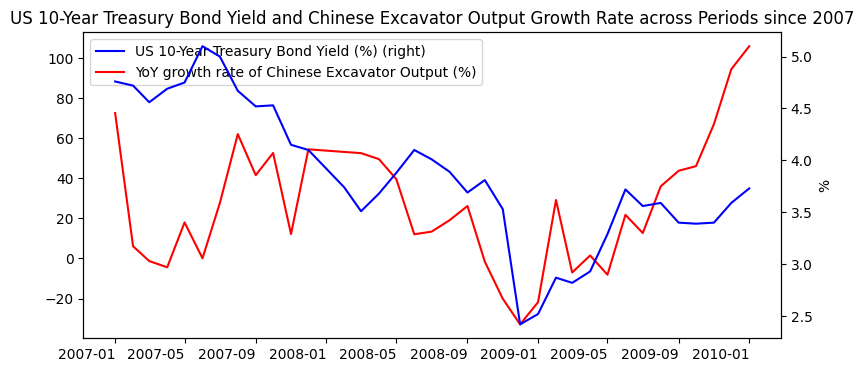

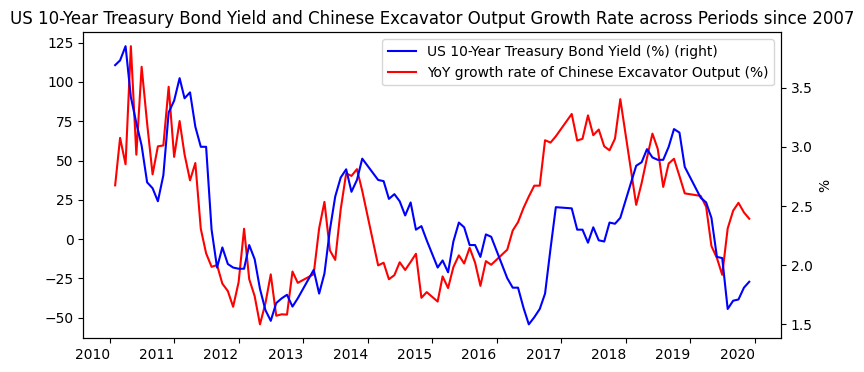

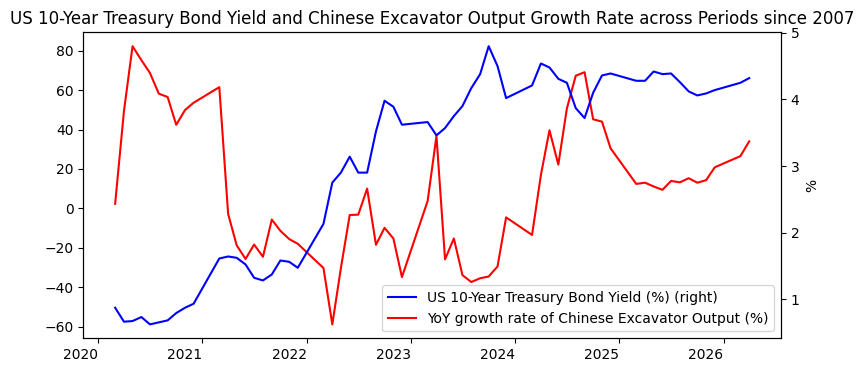

In [16]:
## Plot 1.2: Customize line chart of subgroups
# Rename columns for visualization
merged_df_visual = merged_df
merged_df_visual = merged_df_visual.rename(columns={
    'USTB_10Y_yield': 'US 10-Year Treasury Bond Yield (%)',
    'YoY_CHN_excavator_growth_rate': 'YoY growth rate of Chinese Excavator Output (%)',
    'era': 'Periods since 2007' 
})

merged_df_visual[['US 10-Year Treasury Bond Yield (%)',
                  'YoY growth rate of Chinese Excavator Output (%)',
                  'Periods since 2007']].groupby('Periods since 2007').plot(kind='line',secondary_y=['US 10-Year Treasury Bond Yield (%)'], 
                                                                            xlabel='', ylabel='%', figsize=(9,4.5), color=['blue','red'], rot=0,
                                                                            title= 'US 10-Year Treasury Bond Yield and Chinese Excavator Output Growth Rate across Periods since 2007')

#### 2. Customized scatter plot of primary policy variables

Text(0, 0.5, 'US 10-Year Treasury Bond Yield (%)')

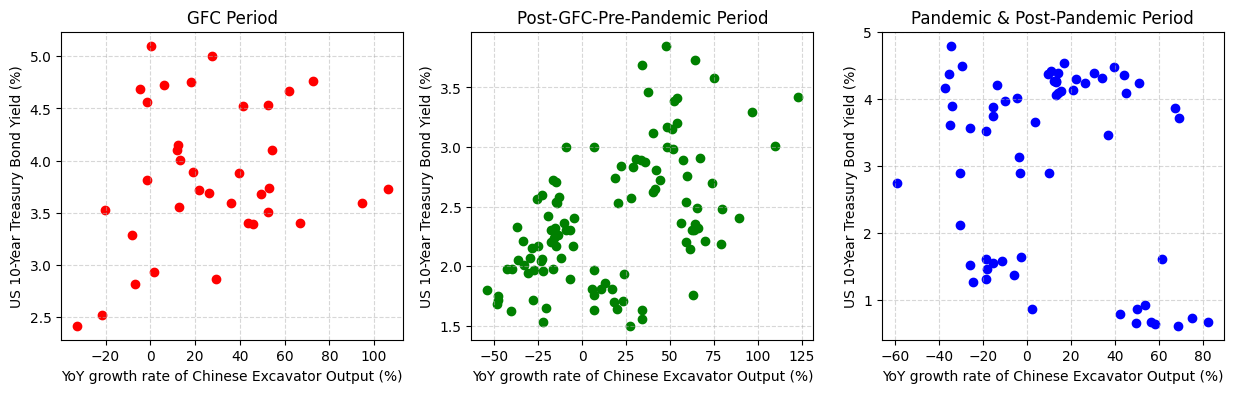

In [17]:
## Plot 2: Customized scatter plot of primary policy variables
# Create subsets of data
merged_df_gfc = merged_df.query("era == 'intra-GFC'")
merged_df_intercrises = merged_df.query("era == 'post-GFC-pre-Pandemic'")
merged_df_pandemic = merged_df.query("era == 'intra-post-Pandemic'")

# Initialize
fig = plt.figure(figsize=(15,4))

# GFC Period
ax1 = fig.add_subplot(1,3,1)
ax1.scatter(x=merged_df_gfc['YoY_CHN_excavator_growth_rate'], y=merged_df_gfc['USTB_10Y_yield'], color='red')
ax1.grid(True, ls='--', alpha=0.5)
ax1.set_title('GFC Period')
ax1.set_xlabel('YoY growth rate of Chinese Excavator Output (%)')
ax1.set_ylabel('US 10-Year Treasury Bond Yield (%)')

# Post-GFC-Pre-Pandemic Period
ax2 = fig.add_subplot(1,3,2)
ax2.scatter(x=merged_df_intercrises['YoY_CHN_excavator_growth_rate'], y=merged_df_intercrises['USTB_10Y_yield'], color='green')
ax2.grid(True, ls='--', alpha=0.5)
ax2.set_title('Post-GFC-Pre-Pandemic Period')
ax2.set_xlabel('YoY growth rate of Chinese Excavator Output (%)')
ax2.set_ylabel('US 10-Year Treasury Bond Yield (%)')

# Pandemic Period
ax3 = fig.add_subplot(1,3,3)
ax3.scatter(x=merged_df_pandemic['YoY_CHN_excavator_growth_rate'], y=merged_df_pandemic['USTB_10Y_yield'], color='blue')
ax3.grid(True, ls='--', alpha=0.5)
ax3.set_title('Pandemic & Post-Pandemic Period')
ax3.set_xlabel('YoY growth rate of Chinese Excavator Output (%)')
ax3.set_ylabel('US 10-Year Treasury Bond Yield (%)')

#### 3. Fit a simple linear regression

In [18]:
## Fit a simple linear regression
import statsmodels.formula.api as smf
# 1. GFC Period
model_gfc = smf.ols(data=merged_df_gfc, formula='USTB_10Y_yield~YoY_CHN_excavator_growth_rate').fit()
model_gfc.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         USTB_10Y_yield   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1.473
Date:                Thu, 28 May 2026   Prob (F-statistic):              0.233
Time:                        17:20:38   Log-Likelihood:                -36.237
No. Observations:                  36   AIC:                             76.47
Df Residuals:                      34   BIC:                             79.64
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         3.7327      0.149     24.981      0.000       3.429       4.036
YoY_CHN_excavator_growth_rate     0.0044      0.004      1.214      0.233      -0.003       0.012
==============================================================================
Omnibus:                        1.965   Durbin-Watson:                   0.172
Prob(Omnibus):                  0.374   Jarque-Bera (JB):                1.330
Skew:                           0.211   Prob(JB):                        0.514
Kurtosis:                       2.159   Cond. No.                         54.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
# 2. Post-GFC-Pre-Pandemic Period
model_intercrises = smf.ols(data=merged_df_intercrises, formula='USTB_10Y_yield~YoY_CHN_excavator_growth_rate').fit()
model_intercrises.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         USTB_10Y_yield   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     40.57
Date:                Thu, 28 May 2026   Prob (F-statistic):           5.25e-09
Time:                        17:20:38   Log-Likelihood:                -70.107
No. Observations:                 106   AIC:                             144.2
Df Residuals:                     104   BIC:                             149.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         2.2768      0.050     45.833      0.000       2.178       2.375
YoY_CHN_excavator_growth_rate     0.0072      0.001      6.369      0.000       0.005       0.009
==============================================================================
Omnibus:                        0.371   Durbin-Watson:                   0.289
Prob(Omnibus):                  0.831   Jarque-Bera (JB):                0.519
Skew:                           0.114   Prob(JB):                        0.771
Kurtosis:                       2.745   Cond. No.                         47.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
# 3. Pandemic Period
model_pandemic = smf.ols(data=merged_df_pandemic, formula='USTB_10Y_yield~YoY_CHN_excavator_growth_rate').fit()
model_pandemic.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         USTB_10Y_yield   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     3.504
Date:                Thu, 28 May 2026   Prob (F-statistic):             0.0661
Time:                        17:20:39   Log-Likelihood:                -107.57
No. Observations:                  62   AIC:                             219.1
Df Residuals:                      60   BIC:                             223.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         3.1292      0.185     16.869      0.000       2.758       3.500
YoY_CHN_excavator_growth_rate    -0.0098      0.005     -1.872      0.066      -0.020       0.001
==============================================================================
Omnibus:                       87.335   Durbin-Watson:                   0.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                7.489
Skew:                          -0.360   Prob(JB):                       0.0236
Kurtosis:                       1.458   Cond. No.                         37.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 4. Overlay the line of best fit

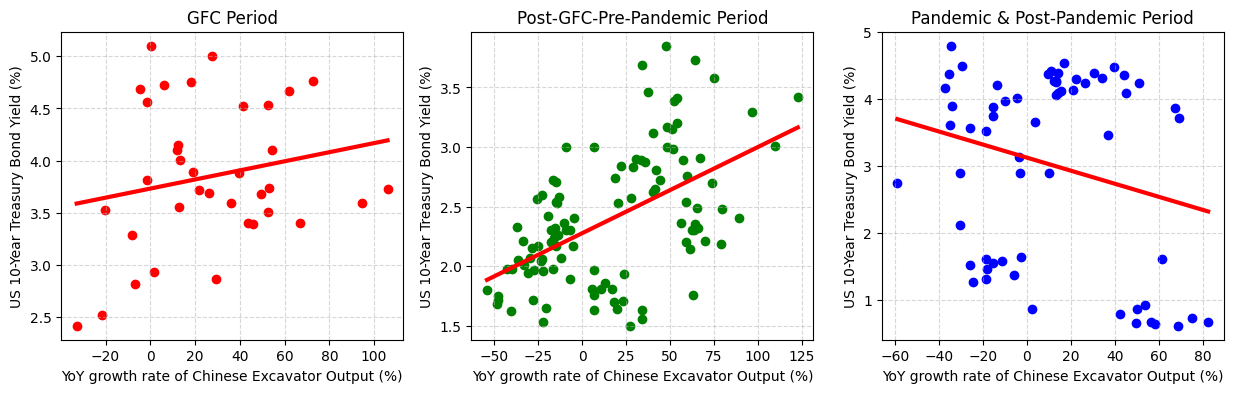

In [21]:
### Overlay the line of best fit
## Initialize
fig = plt.figure(figsize=(15,4))

## GFC Period
# Scatter plot
ax1 = fig.add_subplot(1,3,1)
ax1.scatter(x=merged_df_gfc['YoY_CHN_excavator_growth_rate'], y=merged_df_gfc['USTB_10Y_yield'], color='red')
ax1.grid(True, ls='--', alpha=0.5)
ax1.set_title('GFC Period')
ax1.set_xlabel('YoY growth rate of Chinese Excavator Output (%)')
ax1.set_ylabel('US 10-Year Treasury Bond Yield (%)')

# Fitted line
x_pred = np.linspace(merged_df_gfc['YoY_CHN_excavator_growth_rate'].min(),
                     merged_df_gfc['YoY_CHN_excavator_growth_rate'].max(),
                     100)
y_pred = model_gfc.predict(pd.DataFrame({'YoY_CHN_excavator_growth_rate': x_pred}))
ax1.plot(x_pred, y_pred, color='red', lw=3)


## Post-GFC-Pre-Pandemic Period
# Scatter plot
ax2 = fig.add_subplot(1,3,2)
ax2.scatter(x=merged_df_intercrises['YoY_CHN_excavator_growth_rate'], y=merged_df_intercrises['USTB_10Y_yield'], color='green')
ax2.grid(True, ls='--', alpha=0.5)
ax2.set_title('Post-GFC-Pre-Pandemic Period')
ax2.set_xlabel('YoY growth rate of Chinese Excavator Output (%)')
ax2.set_ylabel('US 10-Year Treasury Bond Yield (%)')

# Fitted line
x_pred = np.linspace(merged_df_intercrises['YoY_CHN_excavator_growth_rate'].min(),
                     merged_df_intercrises['YoY_CHN_excavator_growth_rate'].max(),
                     100)
y_pred = model_intercrises.predict(pd.DataFrame({'YoY_CHN_excavator_growth_rate': x_pred}))
ax2.plot(x_pred, y_pred, color='red', lw=3)


## Pandemic Period
# Scatter plot
ax3 = fig.add_subplot(1,3,3)
ax3.scatter(x=merged_df_pandemic['YoY_CHN_excavator_growth_rate'], y=merged_df_pandemic['USTB_10Y_yield'], color='blue')
ax3.grid(True, ls='--', alpha=0.5)
ax3.set_title('Pandemic & Post-Pandemic Period')
ax3.set_xlabel('YoY growth rate of Chinese Excavator Output (%)')
ax3.set_ylabel('US 10-Year Treasury Bond Yield (%)')

# Fitted line
x_pred = np.linspace(merged_df_pandemic['YoY_CHN_excavator_growth_rate'].min(),
                     merged_df_pandemic['YoY_CHN_excavator_growth_rate'].max(),
                     100)
y_pred = model_pandemic.predict(pd.DataFrame({'YoY_CHN_excavator_growth_rate': x_pred}))
ax3.plot(x_pred, y_pred, color='red', lw=3)

#### Appendix: Estimate lagged period (excavator output growth as leading indicator)

In [22]:
## Appendix: Estimate lagged period (excavator output growth as leading indicator)
from statsmodels.tsa.api import VAR
# Applying VAR model to the time series
model = VAR(merged_df[['USTB_10Y_yield','YoY_CHN_excavator_growth_rate']])
model.select_order(maxlags=6).summary()
# Finding: Excavator output growth in China led 10-year US Treasury Bond yield by approximately a quarter (2-3 months).

c:\Users\lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,7.322,7.355,1514.,7.336
1,3.231,3.331,25.31,3.272
2,3.156,3.322*,23.48,3.224*
3,3.151*,3.383,23.36*,3.245
4,3.158,3.457,23.53,3.279
5,3.176,3.541,23.96,3.324
6,3.206,3.637,24.68,3.380


- *Extra Credit: Write your visualization and regression interpretations here*
##### **Major Findings**
- Preliminary visualization and OLS regressions imply excavator production growth in China has been strongly correlated with 10-year US Treasury Bond yield since 2007. Nevertheless, relationship between the two indicators differs across periods, as two pre-Pandemic eras showed positive correlation while post-Pandemic era showed negative correlation. 
    - Quantitatively: (1) During the GFC period, *ceteris paribus*, one percentage point increase in Chinese excavator production growth rate is associated with 0.44 percentage points increase in 10-year Treasury Bond yield (yet not statistically significant). (2) During inter-crises period, *ceteris paribus*, one percentage point increase in Chinese excavator production growth rate is associated with **0.72 percentage points increase** in 10-year Treasury Bond yield (statistically sigificant at 1% level). (3) During the COVID-19 Pandemic and post-Pandemic period, *ceteris paribus*, one percentage point increase in Chinese excavator production growth rate is associated with **0.98 percentage points decrease** in 10-year Treasury Bond yield (statistically sigificant at 10% level).
- VAR model indicates variation of China's excavator production growth **leads US Treasury Bond yield by approximately a quarter (2-3 months)**. The estimate is robust across different information criteria (i.e., AIC/BIC/FPE/HQIC).


##### **Tentative Explanations**
- One possible reason for positive correlation **before Pandemic**:
    - 10-year Treasury Bond yield is sensitive to inflation expectation. As Chinese excavator production serves as a proxy for domestic investment thereby **demand and prices of critical inputs (particularly raw materials)**, surge in excavator production growth could be correlated with higher inflation expectation and correspondingly higher long-term interest rates.
- Possible reason for negative correlation **since Pandemic**: 
    - As suggested above, a key juncture connecting Chinese excavator production to US long-term interest rate before Pandemic was commodity price dynamics largely driven by downstream demands from China. As China faced economic slowdown since Pandemic, **the previous linkage has been cut off** and the new round of inflation is caused rather by geopolitical turbulence independent of domestic economic dynamics in China. 


### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.